In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/atm_cleaned.csv")

df.head()

,ATM Name,Transaction Date,No Of Withdrawals,No Of XYZ Card Withdrawals,No Of Other Card Withdrawals,Total amount Withdrawn,Amount withdrawn XYZ Card,Amount withdrawn Other Card,Weekday,Festival Religion,...,Rolling_7_Mean,Rolling_14_Mean,Rolling_30_Mean,Lag_1_Day,Lag_7_Day,Lag_14_Day,Lag_30_Day,Rolling_7_Day_Mean,Rolling_14_Day_Mean,Rolling_30_Day_Mean
0,Airport ATM,2011-01-01,98,56,42,10772.76,7440.78,3331.98,Saturday,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Airport ATM,2011-01-02,67,53,14,5748.04,4564.62,1183.42,Sunday,NH,...,NaN,NaN,NaN,10772.76,NaN,NaN,NaN,10772.760000,10772.760000,10772.760000
2,Airport ATM,2011-01-03,109,90,19,12923.46,10738.52,2184.94,Monday,NH,...,NaN,NaN,NaN,5748.04,NaN,NaN,NaN,8260.400000,8260.400000,8260.400000
3,Airport ATM,2011-01-04,113,80,33,11590.24,8953.76,2636.48,Tuesday,NH,...,NaN,NaN,NaN,12923.46,NaN,NaN,NaN,9814.753333,9814.753333,9814.753333
4,Airport ATM,2011-01-05,100,70,30,11342.00,9082.16,2259.84,Wednesday,NH,...,NaN,NaN,NaN,11590.24,NaN,NaN,NaN,10258.625000,10258.625000,10258.625000


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (11589, 33)

Columns:
['ATM Name', 'Transaction Date', 'No Of Withdrawals', 'No Of XYZ Card Withdrawals', 'No Of Other Card Withdrawals', 'Total amount Withdrawn', 'Amount withdrawn XYZ Card', 'Amount withdrawn Other Card', 'Weekday', 'Festival Religion', 'Working Day', 'Holiday Sequence', 'Year', 'Month', 'Day', 'Day_of_Week', 'Is_Weekend', 'Week_of_Year', 'Demand_Outlier', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_30', 'Rolling_7_Mean', 'Rolling_14_Mean', 'Rolling_30_Mean', 'Lag_1_Day', 'Lag_7_Day', 'Lag_14_Day', 'Lag_30_Day', 'Rolling_7_Day_Mean', 'Rolling_14_Day_Mean', 'Rolling_30_Day_Mean']

Data Types:
ATM Name                         object
Transaction Date                 object
No Of Withdrawals                 int64
No Of XYZ Card Withdrawals        int64
No Of Other Card Withdrawals      int64
Total amount Withdrawn          float64
Amount withdrawn XYZ Card       float64
Amount withdrawn Other Card     float64
Weekday                          object
Festival Religion         

In [3]:
df["Total amount Withdrawn"].describe()

count    11589.000000
mean      9003.043831
std       5594.422849
min          1.490000
25%       5216.790000
50%       8085.880000
75%      11653.180000
max      44556.490000
Name: Total amount Withdrawn, dtype: float64

In [4]:
print(
    "Total Cash Withdrawn:",
    df["Total amount Withdrawn"].sum()
)

print(
    "Average Daily Demand:",
    df["Total amount Withdrawn"].mean()
)

print(
    "Median Daily Demand:",
    df["Total amount Withdrawn"].median()
)

print(
    "Maximum Daily Demand:",
    df["Total amount Withdrawn"].max()
)

print(
    "Minimum Daily Demand:",
    df["Total amount Withdrawn"].min()
)

Total Cash Withdrawn: 104336274.96000001
Average Daily Demand: 9003.04383121926
Median Daily Demand: 8085.880000000001
Maximum Daily Demand: 44556.490000000005
Minimum Daily Demand: 1.49


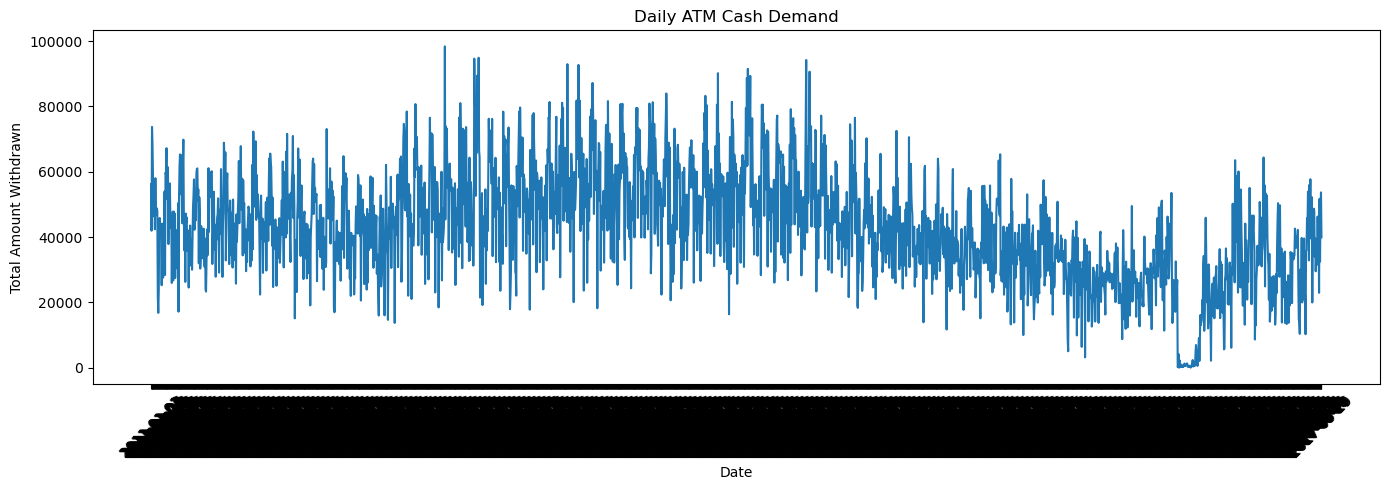

In [5]:
daily_demand = (
    df.groupby("Transaction Date")["Total amount Withdrawn"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["Transaction Date"],
    daily_demand["Total amount Withdrawn"]
)

plt.title("Daily ATM Cash Demand")
plt.xlabel("Date")
plt.ylabel("Total Amount Withdrawn")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
atm_demand = (
    df.groupby("ATM Name")["Total amount Withdrawn"]
    .sum()
    .sort_values(ascending=False)
)

atm_demand

ATM Name
KK Nagar ATM          32314294.73
Christ College ATM    22023356.17
Mount Road ATM        20405768.27
Airport ATM           17527217.01
Big Street ATM        12065638.78
Name: Total amount Withdrawn, dtype: float64

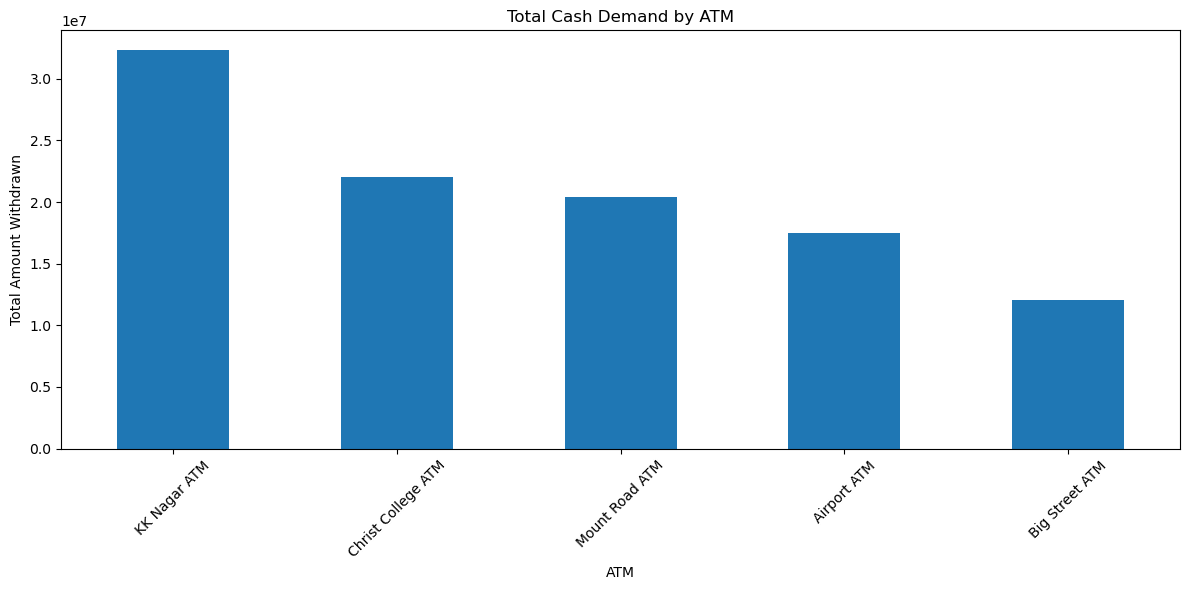

In [7]:
plt.figure(figsize=(12, 6))

atm_demand.plot(kind="bar")

plt.title("Total Cash Demand by ATM")
plt.xlabel("ATM")
plt.ylabel("Total Amount Withdrawn")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
weekday_demand = (
    df.groupby("Weekday")["Total amount Withdrawn"]
    .mean()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand = weekday_demand.reindex(weekday_order)

weekday_demand

Weekday
Monday        9465.015612
Tuesday       9151.776385
Wednesday     9612.941032
Thursday      9357.309952
Friday        8779.586506
Saturday     10183.704873
Sunday        6388.385829
Name: Total amount Withdrawn, dtype: float64

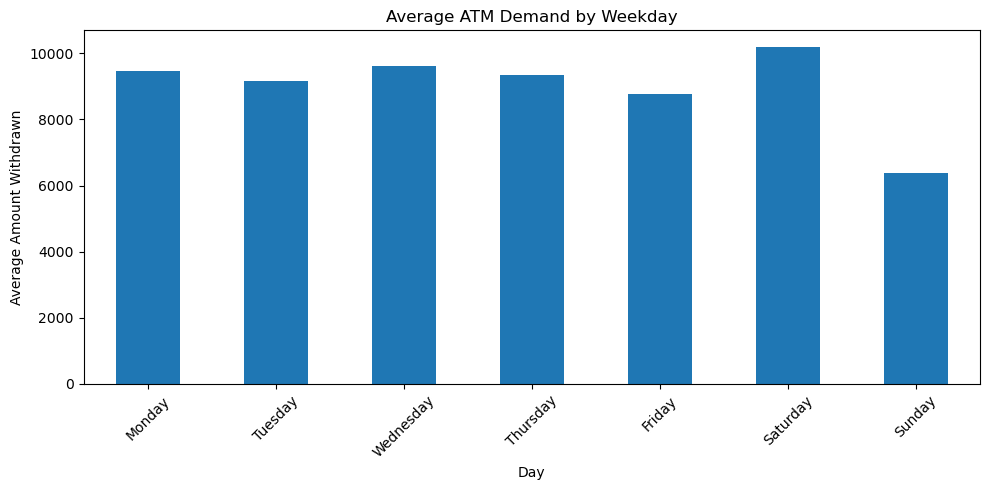

In [9]:
plt.figure(figsize=(10, 5))

weekday_demand.plot(kind="bar")

plt.title("Average ATM Demand by Weekday")
plt.xlabel("Day")
plt.ylabel("Average Amount Withdrawn")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
weekend_analysis = (
    df.groupby("Is_Weekend")["Total amount Withdrawn"]
    .mean()
)

weekend_analysis

Is_Weekend
0    9274.475917
1    8311.037498
Name: Total amount Withdrawn, dtype: float64

In [11]:
weekend_analysis.index = [
    "Weekday" if x == 0 else "Weekend"
    for x in weekend_analysis.index
]

weekend_analysis

Weekday    9274.475917
Weekend    8311.037498
Name: Total amount Withdrawn, dtype: float64

In [12]:
monthly_demand = (
    df.groupby(["Year", "Month"])["Total amount Withdrawn"]
    .sum()
    .reset_index()
)

monthly_demand

,Year,Month,Total amount Withdrawn
0,2011,1,1387135.16
1,2011,2,1228272.26
2,2011,3,1413497.82
3,2011,4,1267038.36
4,2011,5,1411695.94
...,...,...,...
76,2017,5,1135512.84
77,2017,6,953628.06
78,2017,7,849060.52
79,2017,8,966969.08


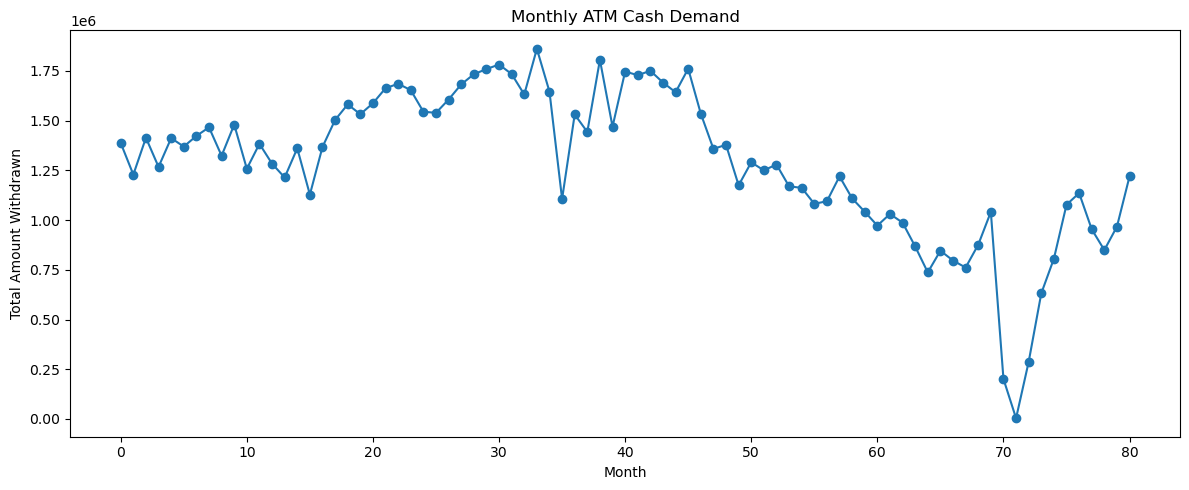

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand["Total amount Withdrawn"],
    marker="o"
)

plt.title("Monthly ATM Cash Demand")
plt.xlabel("Month")
plt.ylabel("Total Amount Withdrawn")

plt.tight_layout()
plt.show()

In [14]:
festival_demand = (
    df.groupby("Festival Religion")["Total amount Withdrawn"]
    .mean()
    .sort_values(ascending=False)
)

festival_demand

Festival Religion
NH    9100.345130
M     8467.332753
C     8282.258655
N     8214.593434
H     7077.954332
Name: Total amount Withdrawn, dtype: float64

In [15]:
working_day_demand = (
    df.groupby("Working Day")["Total amount Withdrawn"]
    .mean()
)

working_day_demand

Working Day
H    8652.148299
W    9266.334724
Name: Total amount Withdrawn, dtype: float64